In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ruta = "https://raw.githubusercontent.com/jamc88/TSMA-II-26-O/refs/heads/main/Datos/o3_promedio_diario_2020_2025.csv"

o3 = pd.read_csv(ruta,parse_dates=["fecha"])
o3 = o3.sort_values("fecha").reset_index(drop=True)
o3

,fecha,o3_promedio
0,2020-01-01,16.218750
1,2020-01-02,16.052083
2,2020-01-03,20.677083
3,2020-01-04,23.041667
4,2020-01-05,25.927083
...,...,...
2187,2025-12-27,27.510417
2188,2025-12-28,32.432292
2189,2025-12-29,28.312500
2190,2025-12-30,24.020833


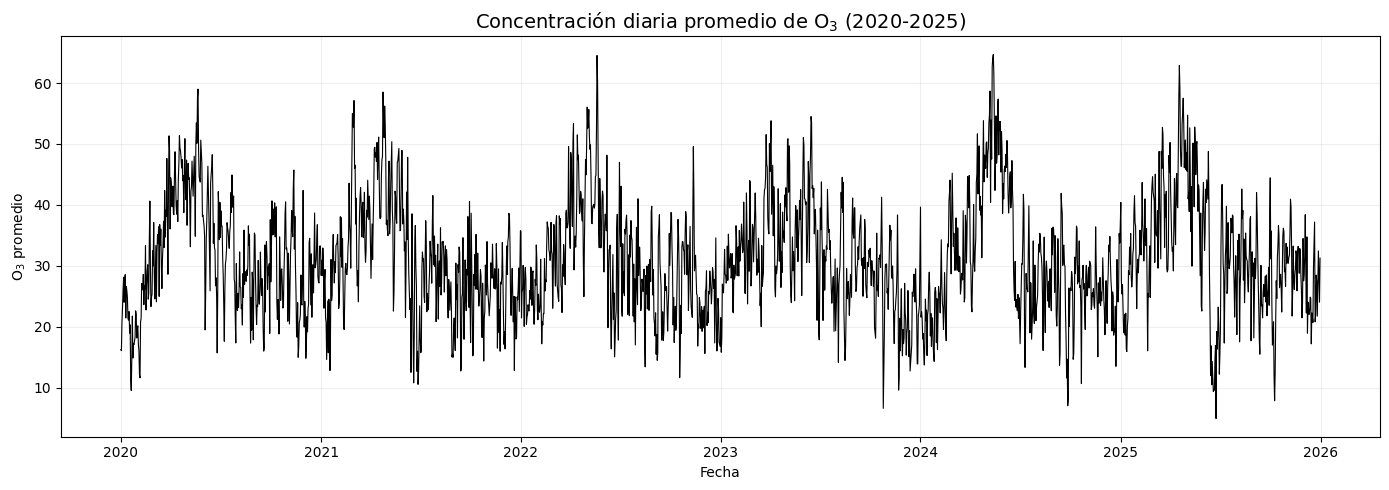

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    o3["fecha"],
    o3["o3_promedio"],
    linewidth=0.8,
    color='black'
)

ax.set_title("Concentración diaria promedio de O$_3$ (2020-2025)",fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [4]:
# Variables de calendario

o3["anio"] = o3["fecha"].dt.year
o3["mes"] = o3["fecha"].dt.month
o3["dia"] = o3["fecha"].dt.day


# Fecha de referencia común

o3["fecha_calendario"] = pd.to_datetime(
    "2000-" + o3["fecha"].dt.strftime("%m-%d"))

nombres_meses = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic"
}

o3["mes_nombre"] = o3["mes"].map(nombres_meses)

o3

,fecha,o3_promedio,anio,mes,dia,fecha_calendario,mes_nombre
0,2020-01-01,16.218750,2020,1,1,2000-01-01,Ene
1,2020-01-02,16.052083,2020,1,2,2000-01-02,Ene
2,2020-01-03,20.677083,2020,1,3,2000-01-03,Ene
3,2020-01-04,23.041667,2020,1,4,2000-01-04,Ene
4,2020-01-05,25.927083,2020,1,5,2000-01-05,Ene
...,...,...,...,...,...,...,...
2187,2025-12-27,27.510417,2025,12,27,2000-12-27,Dic
2188,2025-12-28,32.432292,2025,12,28,2000-12-28,Dic
2189,2025-12-29,28.312500,2025,12,29,2000-12-29,Dic
2190,2025-12-30,24.020833,2025,12,30,2000-12-30,Dic


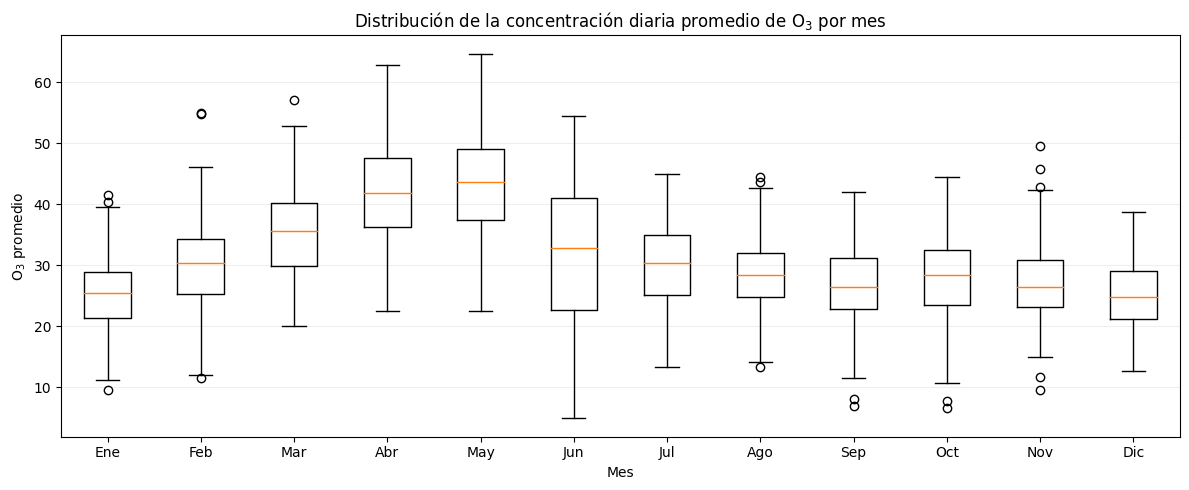

In [6]:
nombres_meses = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic"
}

o3["mes_nombre"] = o3["mes"].map(nombres_meses)

orden_meses = list(nombres_meses.values())


fig, ax = plt.subplots(figsize=(12, 5))

datos_boxplot = [
    o3.loc[o3["mes_nombre"] == mes,"o3_promedio"]
    for mes in orden_meses
]

ax.boxplot(
    datos_boxplot,
    labels=orden_meses,
    showfliers=True
)

ax.set_title("Distribución de la concentración diaria promedio de O$_3$ por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("O$_3$ promedio")
ax.grid(axis="y",alpha=0.2)

plt.tight_layout()
plt.show()

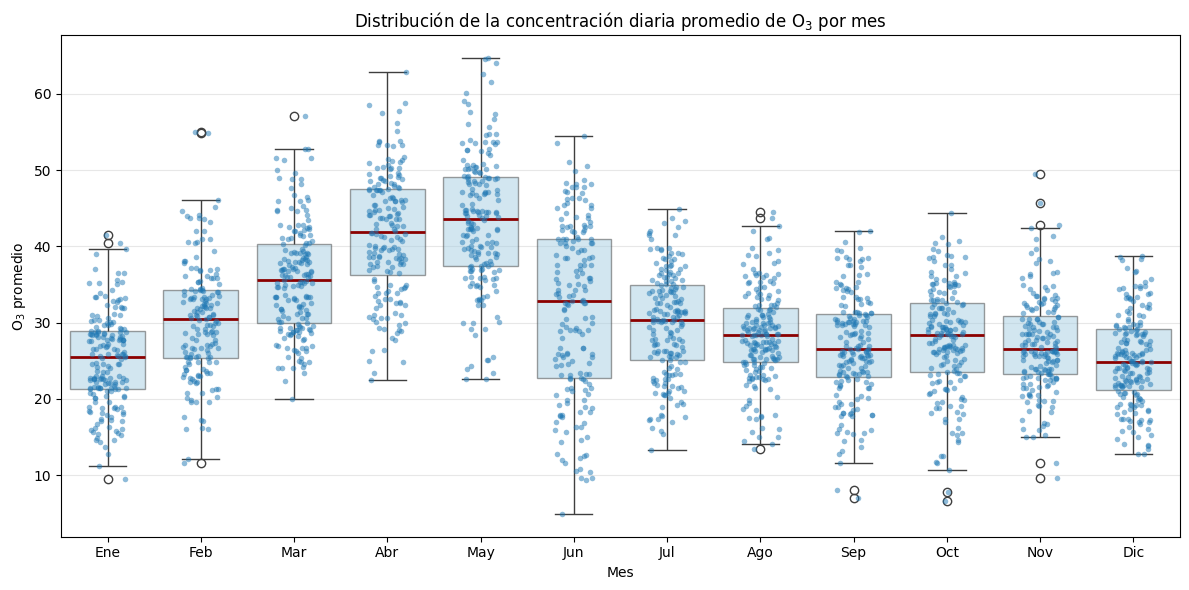

In [7]:
import seaborn as sns

orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=o3, 
    x="mes_nombre", 
    y="o3_promedio", 
    order=orden_meses,
    ax=ax, 
    boxprops=dict(alpha=0.5, facecolor="#a6cee3"),
    medianprops=dict(color="darkred", linewidth=2)
)

sns.stripplot(
    data=o3, 
    x="mes_nombre", 
    y="o3_promedio", 
    order=orden_meses,
    ax=ax, 
    color="#1f78b4", 
    alpha=0.5, 
    jitter=0.2, 
    size=4
)

ax.set_title("Distribución de la concentración diaria promedio de O$_3$ por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("O$_3$ promedio")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

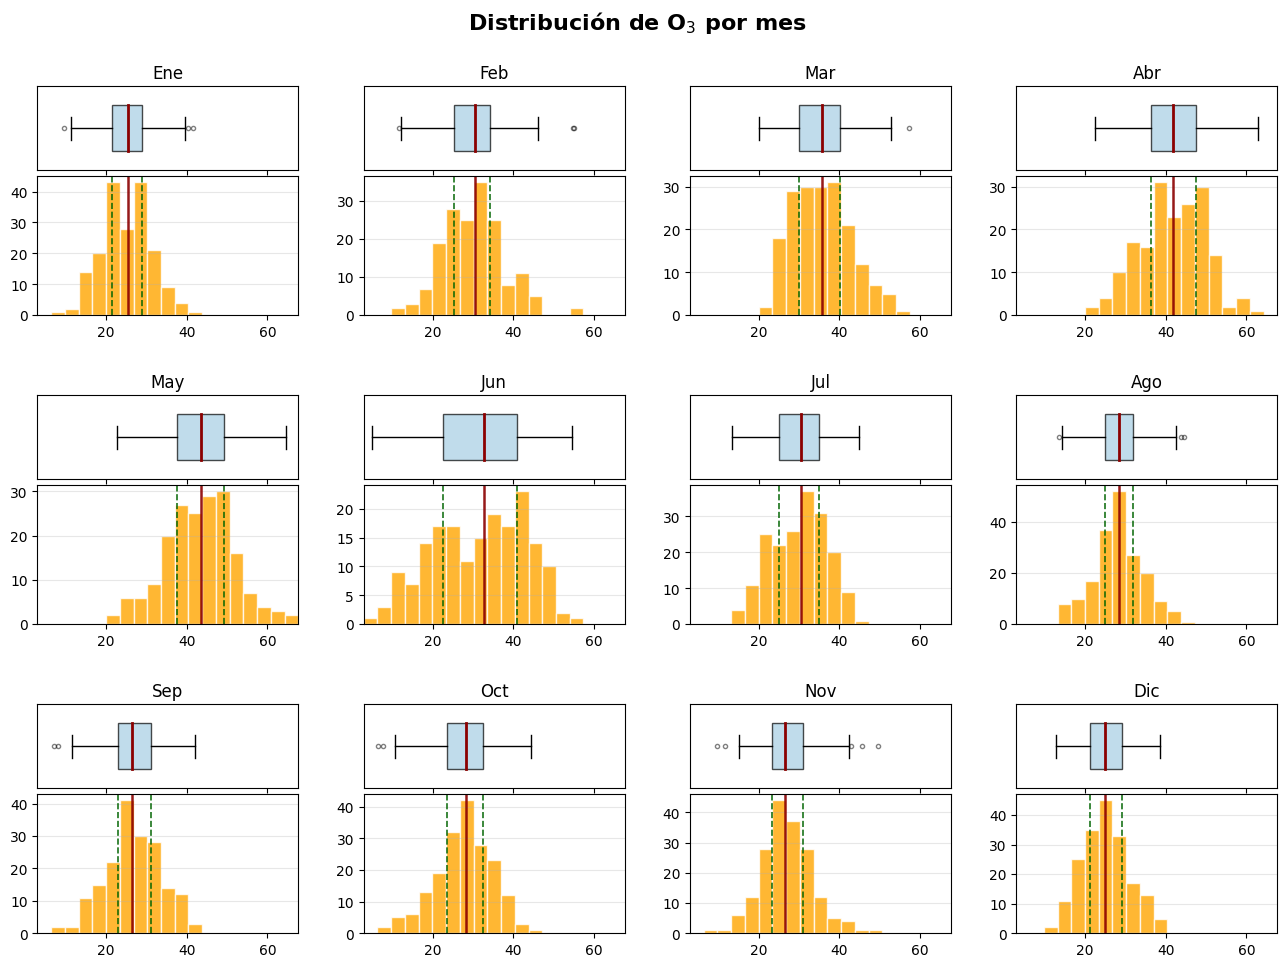

In [16]:
orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

global_min = o3["o3_promedio"].min() - 2
global_max = o3["o3_promedio"].max() + 3
bins_shared = np.linspace(global_min, global_max, 20)

fig = plt.figure(figsize=(16, 11))
gs_master = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.25)

first_ax_box = None

for i, mes in enumerate(orden_meses):
    row = i // 4
    col = i % 4
    
    gs_sub = gs_master[row, col].subgridspec(2, 1, height_ratios=[1.5, 2.5], hspace=0.05)
    
    if i == 0:
        ax_box = fig.add_subplot(gs_sub[0])
        ax_hist = fig.add_subplot(gs_sub[1], sharex=ax_box)
        first_ax_box = ax_box
    else:
        ax_box = fig.add_subplot(gs_sub[0], sharex=first_ax_box)
        ax_hist = fig.add_subplot(gs_sub[1], sharex=first_ax_box)
    
    subset = o3.loc[o3["mes_nombre"] == mes, "o3_promedio"]
    
    mediana_val = subset.median()
    q1_val = subset.quantile(0.25)
    q3_val = subset.quantile(0.75)
    
    ax_box.boxplot(
        subset, 
        vert=False, 
        patch_artist=True, 
        widths=0.55,
        boxprops=dict(facecolor="#a6cee3", alpha=0.7),
        medianprops=dict(color="darkred", linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    ax_box.set(yticks=[], title=mes)
    ax_box.tick_params(labelbottom=False)
    
    ax_hist.hist(subset, bins=bins_shared, color="orange", edgecolor="white", alpha=0.8)
    
    ax_hist.axvline(q1_val, color="darkgreen", linestyle="--", linewidth=1.2, alpha=0.9)
    ax_hist.axvline(q3_val, color="darkgreen", linestyle="--", linewidth=1.2, alpha=0.9)
    ax_hist.axvline(mediana_val, color="darkred", linestyle="-", linewidth=1.8, alpha=0.9)
    
    ax_hist.grid(axis="y", alpha=0.3)
    
    ax_box.set_xlim(global_min, global_max)
    ax_hist.set_xlim(global_min, global_max)

fig.suptitle("Distribución de O$_3$ por mes", fontsize=16, fontweight='bold', y=0.95)
plt.show()

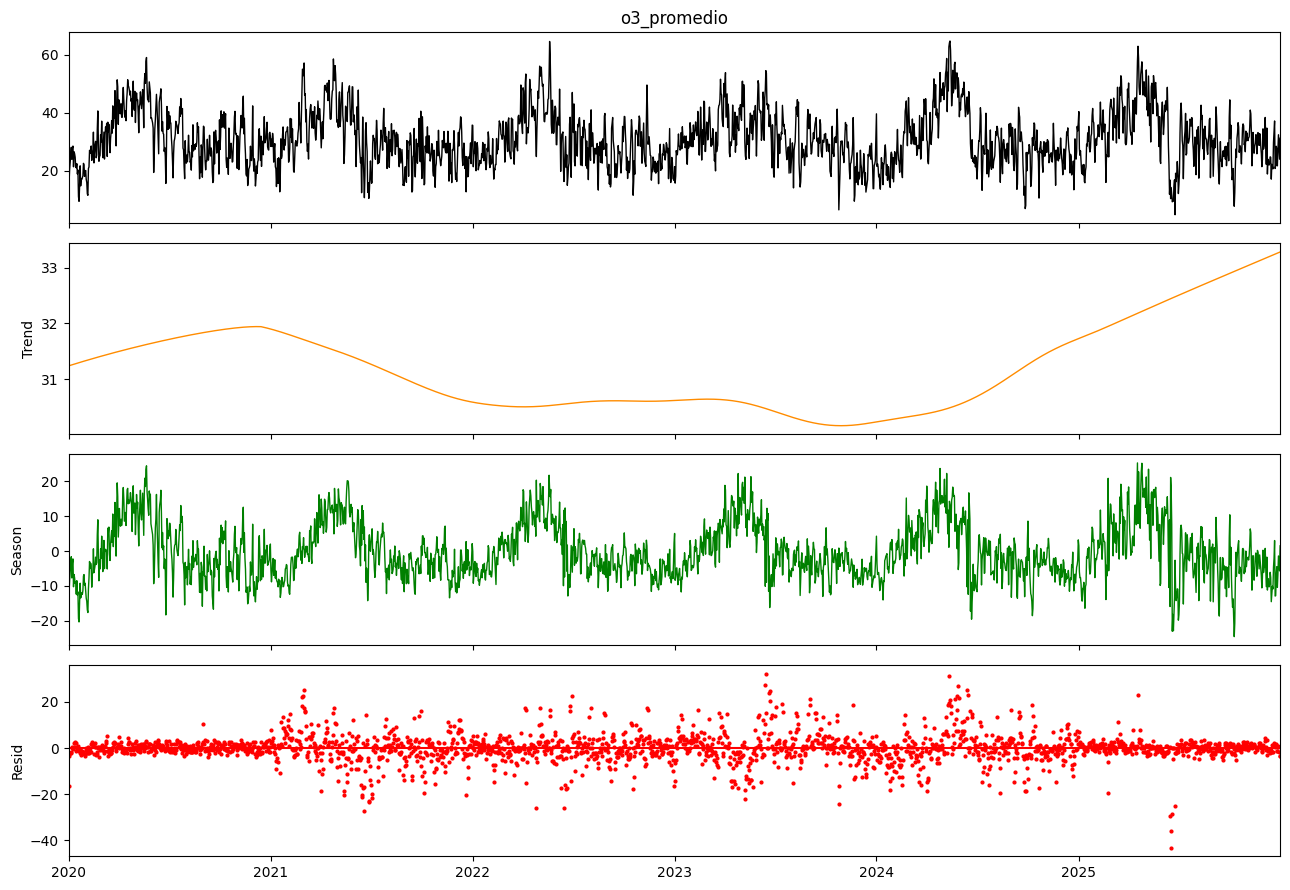

In [17]:
from statsmodels.tsa.seasonal import STL

# Serie con índice temporal

serie_o3 = o3.set_index("fecha")["o3_promedio"].asfreq("D")


# Descomposición STL

stl = STL(
    serie_o3,
    period=365,
    robust=True
)

resultado_stl = stl.fit()


# Componentes

tendencia = resultado_stl.trend
estacional = resultado_stl.seasonal
residuo = resultado_stl.resid

fig = resultado_stl.plot()
fig.set_size_inches(13, 9)


colores = ['black', 'darkorange', 'green', 'red']

for i, (ax, color) in enumerate(zip(fig.axes, colores)):
    for line in ax.get_lines():
        line.set_color(color)
        
        if i == 3:
            line.set_markersize(2.0)  
        else:
            line.set_linewidth(1.0)   
            
plt.tight_layout()
plt.show()

## Autocorrelación: ACF y PACF

Una característica fundamental de una serie temporal es que sus observaciones pueden depender de valores anteriores.

La **función de autocorrelación** (ACF) mide la correlación entre $Y_t$
y su versión desplazada $k$ periodos:

$$
\rho(k)
=\operatorname{Corr}
\left(
Y_t,Y_{t-k}
\right).
$$

Por ejemplo:

$$
\rho(1)
=\operatorname{Corr}
(Y_t,Y_{t-1})
$$

mide la asociación con el día anterior.

De manera similar, $\rho(7)$ representa la asociación con siete días de rezago.



### Autocorrelación parcial

La **función de autocorrelación parcial** (PACF) mide la relación entre $Y_t$ y $Y_{t-k}$ después de eliminar el efecto lineal de los rezagos intermedios.

Por ejemplo, la PACF en $k=2$ mide la relación entre

$$
Y_t
\quad\text{y}\quad
Y_{t-2}
$$

después de controlar por

$$
Y_{t-1}.
$$

Por tanto:

- la ACF describe la dependencia total con los valores pasados;
- la PACF intenta identificar la contribución directa de cada rezago.

Primero estudiaremos los primeros $60$ días de dependencia temporal.

Posteriormente podremos examinar rezagos mayores asociados con la estacionalidad anual.

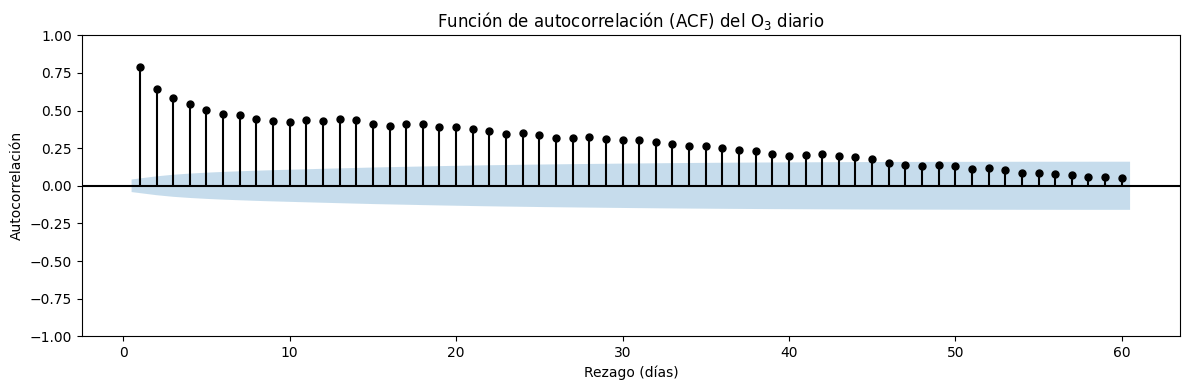

In [18]:
from statsmodels.graphics.tsaplots import (plot_acf,plot_pacf)


# ACF: primeros 60 días

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    serie_o3,
    lags=60,
    zero=False,
    ax=ax,
    color='black',
    vlines_kwargs={'colors': 'black'}
)

ax.set_title("Función de autocorrelación (ACF) del O$_3$ diario")

ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación")

plt.tight_layout()
plt.show()


Se observa una autocorrelación positiva muy alta en los primeros rezagos. En particular, para un rezago de un día la autocorrelación es cercana a $\rho(1)\approx 0.8,$ lo que indica que la concentración de ozono de un día está fuertemente relacionada con la concentración registrada el día anterior.

A medida que aumenta el rezago, la autocorrelación disminuye gradualmente. Sin embargo, esta disminución es relativamente lenta: incluso para rezagos de varias semanas, la ACF continúa tomando valores positivos apreciables.

Este comportamiento indica que la serie presenta una **dependencia temporal persistente**. Es decir, los valores actuales de $O_3$ conservan información de observaciones ocurridas muchos días antes.


La región sombreada alrededor de cero representa un **intervalo de confianza aproximado** para la autocorrelación bajo la hipótesis de que no existe autocorrelación en ese rezago.

De manera aproximada, estos límites suelen construirse para un nivel de confianza del 95\%. 

La interpretación es la siguiente:

- Si una barra de la ACF queda **dentro de la banda**, la autocorrelación observada puede ser compatible con cero.
- Si una barra queda **fuera de la banda**, existe evidencia de que la autocorrelación para ese rezago es distinta de cero.

En esta figura, la mayoría de los rezagos se encuentran por encima de la banda de confianza, lo que indica que existe autocorrelación positiva estadísticamente relevante durante una gran cantidad de días.


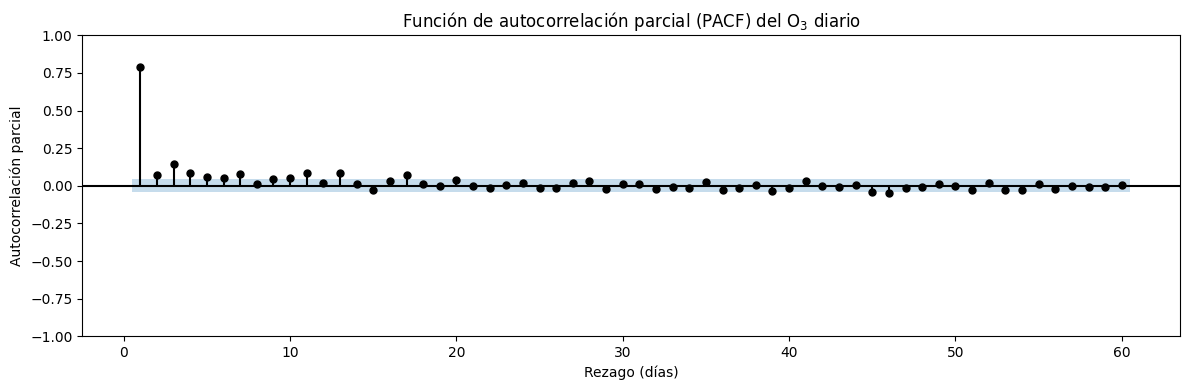

In [19]:
# PACF: primeros 60 días

fig, ax = plt.subplots(figsize=(12, 4))

plot_pacf(
    serie_o3,
    lags=60,
    zero=False,
    method="ywm",
    ax=ax,
    color='black',
    vlines_kwargs={'colors': 'black'}
)

ax.set_title("Función de autocorrelación parcial (PACF) del O$_3$ diario")
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación parcial")
plt.tight_layout()
plt.show()

A diferencia de la ACF, la PACF mide la relación entre $Y_t$ y $Y_{t-k}$ **después de eliminar el efecto lineal de los rezagos intermedios**.

Se observa un valor muy elevado en el primer rezago, $\phi_{11}\approx 0.8,$

lo que indica que la concentración de $O_3$ de un día tiene una relación directa fuerte con la concentración observada el día anterior.

Después del primer rezago, los valores de la PACF disminuyen de manera importante. Algunos rezagos tempranos todavía presentan valores positivos pequeños, pero la mayoría de las autocorrelaciones parciales se encuentran cercanas a cero.

Esto sugiere que una parte considerable de la dependencia temporal observada en la ACF puede explicarse principalmente por los primeros rezagos.


La región sombreada alrededor de cero representa un **intervalo de confianza aproximado**, usualmente al 95\%, bajo la hipótesis de que la autocorrelación parcial correspondiente es igual a cero.

La interpretación es:

- Si una barra se encuentra **dentro de la banda**, la autocorrelación parcial puede ser compatible con cero.
- Si una barra se encuentra **fuera de la banda**, existe evidencia de que ese rezago aporta información temporal adicional.

En esta figura, el rezago $1$ sobresale claramente de la banda de confianza, lo que muestra una dependencia directa muy importante entre días consecutivos.

También pueden observarse algunos rezagos posteriores que superan ligeramente los límites de confianza. Estos podrían indicar dependencias adicionales de menor magnitud, aunque deben interpretarse con precaución.

### Comparación con la ACF

La ACF mostraba una disminución lenta y persistente durante numerosos rezagos, mientras que la PACF presenta un pico dominante en el primer rezago y valores mucho menores posteriormente.

Este contraste es importante:

$$
\text{ACF: dependencia total}
$$

mientras que

$$
\text{PACF: dependencia directa}.
$$

Por lo tanto, aunque la concentración de $O_3$ presenta correlación con valores de muchos días anteriores, gran parte de esta relación puede estar siendo transmitida indirectamente a través de los días intermedios.

### Conclusión

El patrón observado indica una **fuerte dependencia temporal de corto plazo**, dominada principalmente por el rezago de un día.

En términos de modelación, una PACF con un pico muy marcado en $k=1$ y valores considerablemente menores después puede sugerir la presencia de un componente autorregresivo de orden bajo, por ejemplo un término $AR(1)$.

Sin embargo, la identificación de un modelo no debe realizarse únicamente a partir de la PACF. Conviene considerar conjuntamente:

- la ACF;
- la PACF;
- las pruebas de estacionariedad ADF y KPSS;
- y criterios de selección de modelos como AIC o BIC.

In [20]:
# Algunos rezagos específicos

rezagos_interes = [1,2,3,7,14,30,365]

autocorrelaciones = []

for k in rezagos_interes:

    autocorrelaciones.append({
        "rezago_dias": k,
        "autocorrelacion": serie_o3.autocorr(lag=k)
    })

autocorrelaciones = pd.DataFrame(autocorrelaciones)

print("Autocorrelaciones en rezagos seleccionados:")
autocorrelaciones.round(3)

Autocorrelaciones en rezagos seleccionados:


,rezago_dias,autocorrelacion
0,1,0.787
1,2,0.646
2,3,0.583
3,7,0.470
4,14,0.440
5,30,0.306
6,365,0.396


La función de autocorrelación muestra una dependencia temporal importante en la serie diaria de O$_3$.

Para los primeros días obtenemos:

$$
\rho(1)=0.787,
$$

$$
\rho(2)=0.646,
$$



$$
\rho(3)=0.583.
$$

Por tanto, la concentración de O$_3$ de un día está fuertemente relacionada con las concentraciones observadas durante los días inmediatamente anteriores.

La autocorrelación disminuye gradualmente conforme aumenta el rezago, pero permanece positiva incluso después de varias semanas:

$$
\rho(7)=0.470,
$$

$$
\rho(14)=0.440,
$$

$$
\rho(30)=0.306.
$$

Esto indica que la serie presenta **persistencia temporal**.

La PACF muestra un comportamiento diferente. El rezago de un día presenta una autocorrelación parcial claramente dominante, mientras que la contribución adicional de muchos de los rezagos posteriores es considerablemente menor.

Esto significa que buena parte de la asociación observada entre $Y_t$ y valores más alejados puede explicarse indirectamente mediante los valores intermedios.

Finalmente, encontramos

$$
\rho(365)=0.396.
$$

La asociación positiva con el valor observado aproximadamente un año antes es consistente con la componente estacional anual identificada previamente mediante el perfil mensual y la descomposición STL.

Para visualizar esta estructura anual examinaremos ahora la ACF hasta $400$ días.

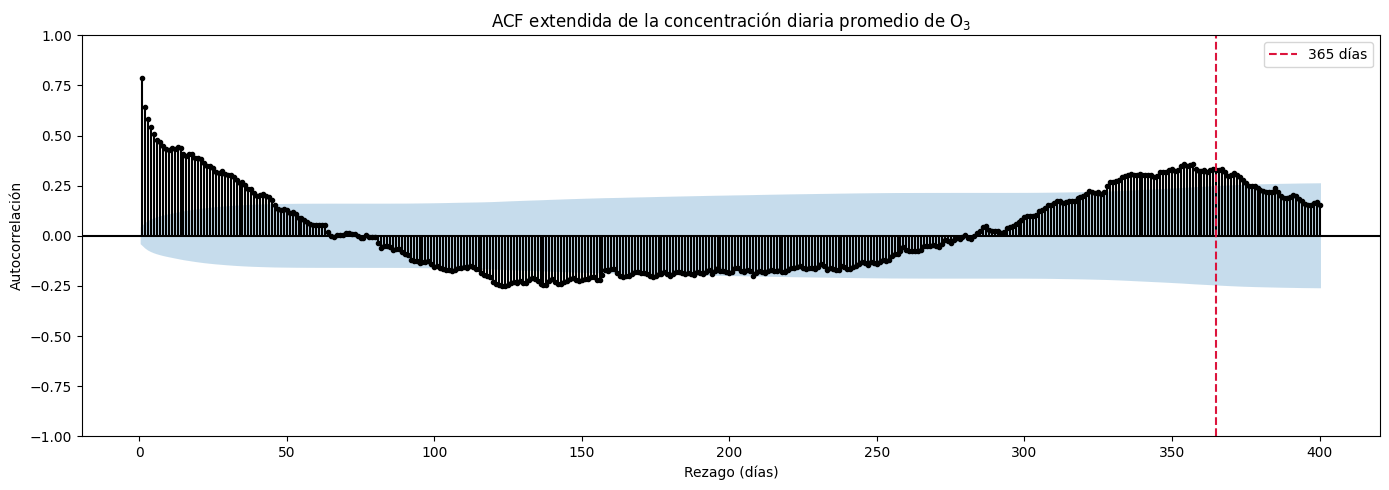

In [21]:
# ACF extendida para observar el ciclo anual

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    serie_o3,
    lags=400,
    zero=False,
    ax=ax,
    color='black',
    vlines_kwargs={'colors': 'black'},
    markersize=3
)

ax.axvline(
    365,
    linestyle="--",
    linewidth=1.5,
    label="365 días",
    color='crimson'
)

ax.set_title("ACF extendida de la concentración diaria promedio de O$_3$")
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Autocorrelación alrededor del ciclo anual

rezagos_anuales = [330,345,360,365,370,380,400]

acf_anual = pd.DataFrame({
    "rezago_dias": rezagos_anuales,
    "autocorrelacion": [
        serie_o3.autocorr(lag=k)
        for k in rezagos_anuales
    ]
})

acf_anual.round(3)

,rezago_dias,autocorrelacion
0,330,0.324
1,345,0.357
2,360,0.393
3,365,0.396
4,370,0.370
5,380,0.278
6,400,0.189


### Interpretación de la ACF extendida

La ACF extendida muestra una estructura temporal de largo alcance.

Después de una autocorrelación positiva fuerte en los primeros días, la asociación disminuye progresivamente, se vuelve negativa durante una parte importante del año y posteriormente vuelve a aumentar.

Alrededor de un año obtenemos:

$$
\rho(330)=0.324,
$$

$$
\rho(345)=0.357,
$$

$$
\rho(360)=0.393,
$$

$$
\rho(365)=0.396,
$$

$$
\rho(370)=0.370.
$$

La presencia de una zona amplia de autocorrelación positiva alrededor de los $365$ días es consistente con una **estacionalidad anual**.

No es necesario que el máximo ocurra exactamente en $365$ días. En fenómenos ambientales, el patrón estacional puede desplazarse ligeramente entre años debido a variaciones meteorológicas y otros factores.

En conjunto, los resultados de:

- perfiles mensuales;
- diagramas de caja;
- descomposición STL;
- ACF extendida;

apuntan a una estructura anual importante en la serie de O$_3$.

### Prueba ADF

La prueba Augmented Dickey--Fuller plantea:

$$
H_0:
\text{la serie tiene raíz unitaria}
$$

frente a

$$
H_1:
\text{la serie es estacionaria}.
$$

Por tanto, un valor pequeño de $p$ favorece rechazar la hipótesis de no estacionariedad.



### Prueba KPSS

La prueba KPSS plantea la hipótesis contraria:

$$
H_0:
\text{la serie es estacionaria}
$$

frente a

$$
H_1:
\text{la serie no es estacionaria}.
$$

Por ello, ambas pruebas se complementan.

Una lectura conjunta puede resumirse como:

| ADF | KPSS | Interpretación |
|---|---|---|
| rechaza $H_0$ | no rechaza $H_0$ | evidencia de estacionariedad |
| no rechaza $H_0$ | rechaza $H_0$ | evidencia de no estacionariedad |
| ambos rechazan | ambos no rechazan | resultado ambiguo / estructura más compleja |

Aplicaremos ambas pruebas primero a la serie original.

In [23]:
from statsmodels.tsa.stattools import adfuller, kpss


# Prueba ADF

resultado_adf = adfuller(serie_o3,autolag="AIC")

adf_stat = resultado_adf[0]
adf_pvalue = resultado_adf[1]
adf_lags = resultado_adf[2]


# Prueba KPSS

resultado_kpss = kpss(
    serie_o3,
    regression="c",
    nlags="auto"
)

kpss_stat = resultado_kpss[0]
kpss_pvalue = resultado_kpss[1]
kpss_lags = resultado_kpss[2]


# Resultados

print("Prueba ADF")
print("-" * 30)
print(f"Estadístico: {adf_stat:.4f}")
print(f"p-value: {adf_pvalue:.4f}")
print(f"Rezagos utilizados: {adf_lags}")

print("\nPrueba KPSS")
print("-" * 30)
print(f"Estadístico: {kpss_stat:.4f}")
print(f"p-value: {kpss_pvalue:.4f}")
print(f"Rezagos utilizados: {kpss_lags}")

Prueba ADF
------------------------------
Estadístico: -5.0010
p-value: 0.0000
Rezagos utilizados: 16

Prueba KPSS
------------------------------
Estadístico: 0.0585
p-value: 0.1000
Rezagos utilizados: 26


/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_1504/2504609690.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(serie_o3,autolag="AIC")
/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_1504/2504609690.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  resultado_kpss = kpss(
/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_1504/2504609690.py:15: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True).

In [24]:
# Interpretación automática sencilla

alpha = 0.05

print("\nInterpretación con alpha = 0.05")
print("-" * 40)

if adf_pvalue < alpha:
    print("ADF: se rechaza H0 -> evidencia a favor de estacionariedad.")
else:
    print("ADF: no se rechaza H0 -> evidencia de raíz unitaria.")

if kpss_pvalue < alpha:
    print("KPSS: se rechaza H0 -> evidencia de no estacionariedad.")
else:
    print("KPSS: no se rechaza H0 -> no hay evidencia contra la estacionariedad.")


Interpretación con alpha = 0.05
----------------------------------------
ADF: se rechaza H0 -> evidencia a favor de estacionariedad.
KPSS: no se rechaza H0 -> no hay evidencia contra la estacionariedad.


### Interpretación de las pruebas de estacionariedad

Para la serie diaria original obtuvimos:

$$
\text{ADF}:
\qquad
p<0.001,
$$

por lo que rechazamos la hipótesis nula de raíz unitaria.

Por otro lado:

$$
\text{KPSS}:
\qquad
p>0.10,
$$

por lo que no rechazamos la hipótesis nula de estacionariedad.

Ambas pruebas proporcionan, por tanto, evidencia compatible con una serie estacionaria en nivel.

Sin embargo, esto no significa que la serie carezca de estacionalidad.

En los análisis anteriores observamos:

- un perfil mensual claramente diferente entre meses;
- una componente estacional importante mediante STL;
- autocorrelación positiva alrededor de $365$ días.

Por ello debemos distinguir entre:

$$
\boxed{
\text{raíz unitaria}
\neq
\text{estacionalidad}
}
$$

Una serie puede no presentar una raíz unitaria y, al mismo tiempo, contener una estructura estacional importante.

El mensaje principal es que la estacionariedad debe evaluarse utilizando conjuntamente:

$$
\boxed{
\text{gráficas}
+
\text{descomposición}
+
\text{ACF/PACF}
+
\text{pruebas estadísticas}
}
$$

y no mediante una sola prueba.

## Eliminación de la componente estacional

La descomposición STL proporciona una estimación de la componente estacional:

$$
S_t.
$$

Podemos construir una serie desestacionalizada mediante

$$
Y_t^{*}
=
Y_t-S_t.
$$

Esta transformación conserva aproximadamente la tendencia y las variaciones irregulares:

$$
Y_t^{*}
=
T_t+R_t.
$$

El objetivo es comparar la serie original con una versión en la que el patrón anual estimado ha sido eliminado.

Posteriormente examinaremos si la estructura de autocorrelación cambia después de retirar la estacionalidad.

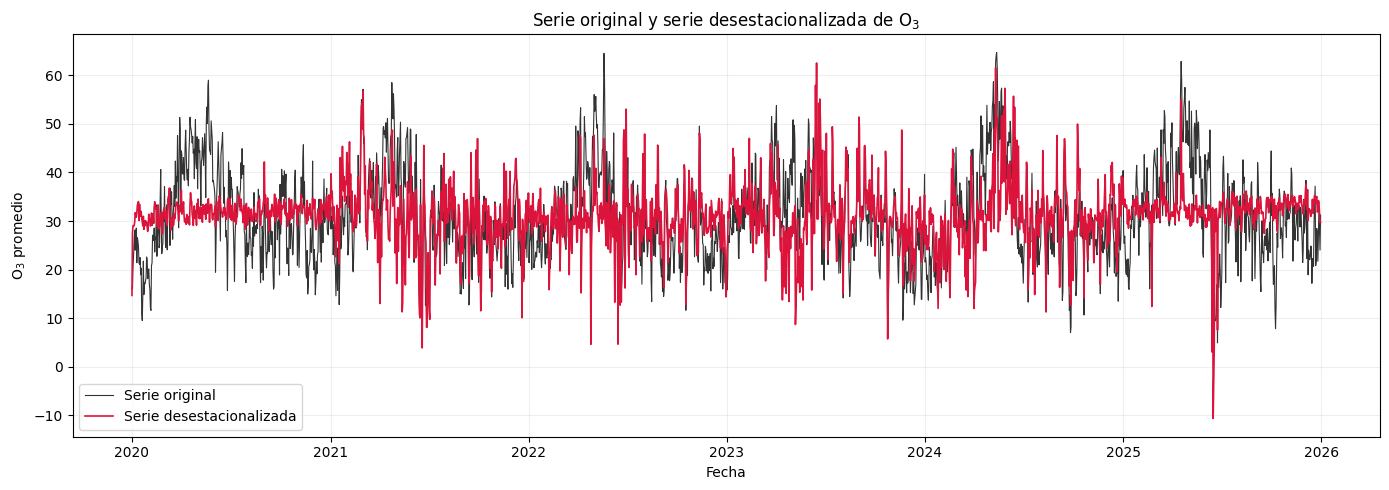

In [25]:
# Serie desestacionalizada

serie_desestacionalizada = serie_o3 - estacional

# Comparación gráfica

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    serie_o3.index,
    serie_o3,
    linewidth=0.8,
    alpha=0.8,
    label="Serie original",
    color='black'
)

ax.plot(
    serie_desestacionalizada.index,
    serie_desestacionalizada,
    linewidth=1.2,
    label="Serie desestacionalizada",
    color='crimson'
)

ax.set_title(
    "Serie original y serie desestacionalizada de O$_3$"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

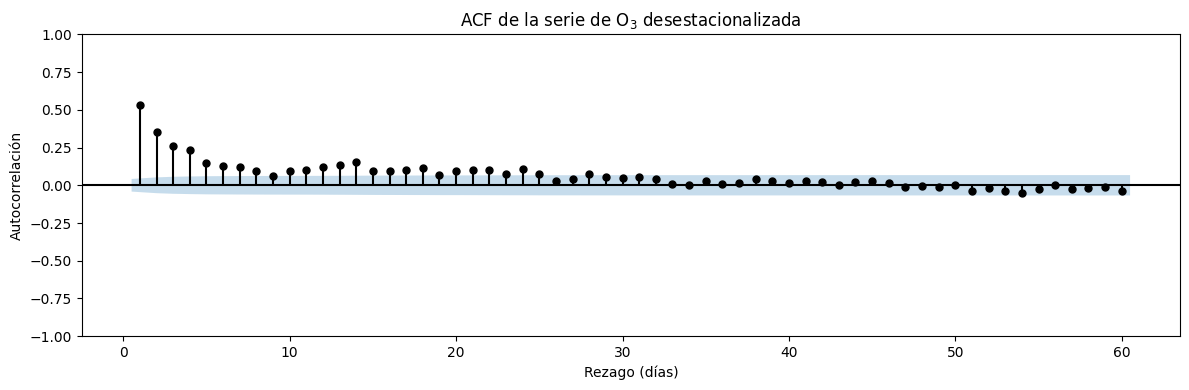

In [26]:
# ACF de la serie desestacionalizada

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    serie_desestacionalizada,
    lags=60,
    zero=False,
    ax=ax,
    color='black',
    vlines_kwargs={'colors': 'black'}
)

ax.set_title("ACF de la serie de O$_3$ desestacionalizada")

ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación")

plt.tight_layout()
plt.show()

In [27]:
# Comparación de autocorrelaciones

rezagos_comparacion = [1,7,30,365]

comparacion_acf = pd.DataFrame({
    "rezago_dias": rezagos_comparacion,
    "serie_original": [
        serie_o3.autocorr(lag=k)
        for k in rezagos_comparacion
    ],
    "serie_desestacionalizada": [
        serie_desestacionalizada.autocorr(lag=k)
        for k in rezagos_comparacion
    ]
})

comparacion_acf.round(3)

,rezago_dias,serie_original,serie_desestacionalizada
0,1,0.787,0.533
1,7,0.470,0.118
2,30,0.306,0.047
3,365,0.396,-0.084


La eliminación de la componente estacional modifica considerablemente la estructura de dependencia temporal.

Para la serie original teníamos:

$$
\rho(1)=0.787,
\qquad
\rho(7)=0.470,
\qquad
\rho(30)=0.306,
\qquad
\rho(365)=0.396.
$$

Después de retirar la componente estacional estimada mediante STL obtenemos aproximadamente:

$$
\rho^*(1)=0.533,
$$

$$
\rho^*(7)=0.118,
$$

$$
\rho^*(30)=0.047,
$$

y

$$
\rho^*(365)=-0.084.
$$

La autocorrelación alrededor de un año prácticamente desaparece, lo que indica que STL capturó una parte importante del ciclo anual.

También disminuye considerablemente la dependencia en escalas de varias semanas.

Sin embargo,

$$
\rho^*(1)=0.533
$$

permanece relativamente elevado.

Esto muestra que la serie contiene al menos dos tipos de dependencia:

$$
\boxed{
\text{estructura estacional de largo plazo}
+
\text{persistencia de corto plazo}
}
$$

Eliminar la estacionalidad no implica que las observaciones se vuelvan independientes.

Además, la serie desestacionalizada puede tomar valores negativos porque representa

$$
Y_t-S_t,
$$

y no una concentración física directamente observada.

## Estacionariedad después de eliminar la estacionalidad

La serie original ya presentó evidencia compatible con estacionariedad:

- ADF rechazó la presencia de una raíz unitaria;
- KPSS no rechazó la estacionariedad.

Sin embargo, también identificamos una componente estacional anual importante.

Ahora repetiremos ambas pruebas sobre la serie desestacionalizada:

$$
Y_t^*=Y_t-S_t.
$$

El objetivo no es demostrar que era obligatorio transformar la serie, sino comprobar si las conclusiones sobre estacionariedad se mantienen después de retirar el patrón estacional.

Este ejemplo también permite distinguir dos conceptos:

$$
\boxed{
\text{estacionariedad}
\neq
\text{independencia temporal}
}
$$

Una serie puede ser estacionaria y, al mismo tiempo, presentar autocorrelación entre observaciones consecutivas.

In [28]:
# ADF sobre la serie desestacionalizada

adf_des = adfuller(serie_desestacionalizada,autolag="AIC")

adf_des_stat = adf_des[0]
adf_des_pvalue = adf_des[1]


# KPSS sobre la serie desestacionalizada

kpss_des = kpss(
    serie_desestacionalizada,
    regression="c",
    nlags="auto"
)

kpss_des_stat = kpss_des[0]
kpss_des_pvalue = kpss_des[1]


# Comparación

comparacion_estacionariedad = pd.DataFrame({
    "serie": ["Original","Desestacionalizada"],
    "ADF_estadistico": [adf_stat,adf_des_stat],
    "ADF_pvalue": [adf_pvalue,adf_des_pvalue],
    "KPSS_estadistico": [kpss_stat,kpss_des_stat],
    "KPSS_pvalue": [kpss_pvalue,kpss_des_pvalue]
})

comparacion_estacionariedad.round(4)

/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_1504/202845234.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_des = adfuller(serie_desestacionalizada,autolag="AIC")
/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_1504/202845234.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_des = kpss(
/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_1504/202845234.py:11: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True)

,serie,ADF_estadistico,ADF_pvalue,KPSS_estadistico,KPSS_pvalue
0,Original,-5.0010,0.0,0.0585,0.1
1,Desestacionalizada,-6.5784,0.0,0.1616,0.1


In [29]:
# Interpretación automática

alpha = 0.05

print("Serie desestacionalizada")
print("-" * 35)

if adf_des_pvalue < alpha:
    print("ADF: se rechaza H0 -> no hay evidencia de raíz unitaria.")
else:
    print("ADF: no se rechaza H0 -> posible raíz unitaria.")

if kpss_des_pvalue < alpha:
    print("KPSS: se rechaza H0 -> evidencia contra la estacionariedad.")
else:
    print("KPSS: no se rechaza H0 -> no hay evidencia contra la estacionariedad.")

Serie desestacionalizada
-----------------------------------
ADF: se rechaza H0 -> no hay evidencia de raíz unitaria.
KPSS: no se rechaza H0 -> no hay evidencia contra la estacionariedad.


Conclusión: **la desestacionalización no cambia la conclusión sobre estacionariedad**, pero sí modifica claramente la estructura de autocorrelación.

La serie desestacionalizada incluso presenta un estadístico ADF más negativo:

$$
-6.5784
$$

frente a

$$
-5.0010
$$

de la original, y KPSS sigue sin aportar evidencia contra la estacionariedad. 

## Conclusiones

En este notebook analizamos una serie diaria de O$_3$ correspondiente al periodo 2020--2025.

Los principales resultados fueron:

### 1. Estructura estacional

El análisis mensual mostró un patrón anual claro:

- las concentraciones tienden a aumentar entre enero y mayo;
- abril y mayo presentan los niveles centrales más altos;
- durante el segundo semestre los niveles son generalmente menores.

La descomposición STL confirmó que la componente estacional es considerablemente más importante que la tendencia de largo plazo:

$$
F_T=0.012,
$$

$$
F_S=0.559.
$$



### 2. Dependencia temporal

La serie presenta una fuerte persistencia de corto plazo:

$$
\rho(1)=0.787.
$$

La autocorrelación disminuye gradualmente conforme aumenta el rezago, pero también aparece nuevamente una asociación positiva alrededor de un año:

$$
\rho(365)=0.396.
$$

Esto es consistente con la estacionalidad anual observada.



### 3. Efecto de la desestacionalización

Después de retirar la componente estacional mediante STL:

$$
Y_t^*=Y_t-S_t,
$$

la autocorrelación anual disminuyó de

$$
0.396
$$

a aproximadamente

$$
-0.084.
$$

Sin embargo, la dependencia de corto plazo permaneció:

$$
\rho^*(1)=0.533.
$$

Por tanto, eliminar la estacionalidad no elimina toda la memoria temporal de la serie.



### 4. Estacionariedad

Las pruebas ADF y KPSS proporcionaron resultados compatibles con estacionariedad tanto para la serie original como para la serie desestacionalizada.

Para la serie original:

$$
p_{\mathrm{ADF}}<0.001,
\qquad
p_{\mathrm{KPSS}}>0.10.
$$

Para la serie desestacionalizada se obtuvo la misma conclusión.

Esto permite distinguir tres conceptos diferentes:

$$
\boxed{
\text{estacionalidad}
\neq
\text{no estacionariedad}
\neq
\text{independencia temporal}
}
$$

Una serie puede ser estacionaria y, al mismo tiempo, presentar patrones estacionales y autocorrelación significativa.



## Flujo realizado

Durante el notebook seguimos el esquema:

$$
\boxed{
\text{serie temporal}
\rightarrow
\text{perfil estacional}
\rightarrow
\text{STL}
\rightarrow
\text{ACF/PACF}
\rightarrow
\text{estacionariedad}
}
$$

Estas herramientas serán útiles posteriormente para seleccionar transformaciones, construir características temporales y definir estrategias apropiadas de modelado.